In [1]:
%reload_ext autoreload
%autoreload 2

import sys, os
sys.path.append("../")

import numpy as np
import corner
import pickle
from tqdm import tqdm

In [2]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rc_file('../notebooks/matplotlibrc')

In [3]:
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18

In [ ]:
samples =  pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))

plot_var_names = ['gamma_ps', 'gamma_poiss', 'f_bulge_ps', 'C', 'zs']

n_bins_1d = 30
bins_1d_arr = []
for vn in plot_var_names:
    # vmin = np.min([np.min(s[vn]) for _, s in samples.items()])
    # vmax = np.max([np.max(s[vn]) for _, s in samples.items()])
    vmin = np.min(samples[vn])
    vmax = np.max(samples[vn])
    bins_1d_arr.append(np.linspace(vmin, vmax, n_bins_1d + 1))

figure = corner.corner(
    samples,
    bins_1d_arr=bins_1d_arr,
    var_names=plot_var_names,
    show_titles=False,
    title_kwargs={"fontsize": 18},
    levels = [0.68, 0.95],
    color = 'firebrick',
    plot_contours=True,
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=True, smooth1d=True,
    fig=None,
    alpha=1.0
)
#plt.savefig('corner_for_draft.pdf')

In [4]:
from getdist import plots, MCSamples
import getdist

In [5]:
saved_samples =  pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))
post_plot = np.concatenate([
    [saved_samples['gamma_ps']],
    [saved_samples['gamma_poiss']],
    [saved_samples['f_bulge_ps']],
    [saved_samples['zs']],
    [saved_samples['C']]], axis=0)

In [11]:
post_plot = np.concatenate([
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))]], axis=0)

In [7]:
def invert_rgba(rgba):
    rgb = rgba[:3]
    a = rgba[-1]
    return tuple(np.array([1, 1, 1] - np.array(rgb))) + (a,)

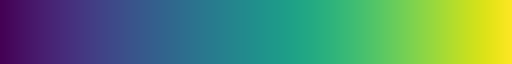

In [8]:
mpl.cm.get_cmap('viridis')

In [6]:
g = plots.get_subplot_plotter(subplot_size=1.4)
g.settings.axes_fontsize=16
g.settings.fontsize=16
g.settings.rc_sizes(axes_fontsize=22, lab_fontsize=22)
g.settings.alpha_filled_add=0.4
g.settings.title_limit_fontsize=19
g.settings.title_limit=1
g.settings.title_limit_labels=0
g.settings.solid_contour_palefactor = 0.9

#color = mpl.colors.to_hex(invert_rgba(mpl.cm.get_cmap('viridis')(0.7)), keep_alpha=True)
color = 'firebrick'

names = [r'\gamma_\mathrm{PS}', r'\gamma_\mathrm{poiss}', r'f_\mathrm{bulge,\,PS}', r'z_s', r'C']
samples = MCSamples(samples=post_plot.T, names = names, labels = names)

g.triangle_plot([samples],
    line_args=[{'lw':2, 'color':color}],
    filled=True,
    # title_limit=1,
    contour_colors=[color],)
g.export('np_sviiaf_par8.pdf')

Removed no burn in
